In [9]:
from modeller import *
from modeller.automodel import *

env = Environ()
env.io.atom_files_directory = ['/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/abinitiolr2/']

# Lê apenas átomos ATOM (ignora HETATM como água, ligantes)
env.io.hetatm = False
env.io.water = False

class MyModel(AutoModel):
    pass
    # def select_atoms(self):
    #     """
    #     Refina apenas:
    #     1. As regiões de junção (onde o fragmento Rosetta foi encaixado)
    #     2. As posições das 7 mutações
    #     """
        
    #     # Substitua pelos resíduos reais da junção (bordas do fragmento Rosetta)
    #     juncao_n = self.residue_range('279:A', '284:A')  # N-terminal da junção
    #     juncao_c = self.residue_range('331:A', '336:A')  # C-terminal da junção
        
    #     # Substitua pelos resíduos das 7 mutações
    #     mutacoes = Selection(
    #         self.residue_range('228:A', '230:A'),  # 229
    #         self.residue_range('266:A', '268:A'),  # 267
    #         self.residue_range('365:A', '367:A'),  # 366
    #         self.residue_range('491:A', '493:A'),  # 492
    #         self.residue_range('561:A', '563:A'),  # 562
    #         self.residue_range('603:A', '605:A'),  # 604
    #         self.residue_range('609:A', '611:A'),  # 610
    #     )

        
    #     return Selection(juncao_n, juncao_c, mutacoes)

In [10]:
a = MyModel(
    env,
    alnfile  = 'structures.ali',
    knowns   = 'template_sorted',
    sequence = 'target'
)

a.starting_model = 1
a.ending_model   = 50

a.make()

chk_str_686W> Residue  281:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/abinitiolr2/template_sorted.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  282:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/abinitiolr2/template_sorted.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  333:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/abinitiolr2/template_sorted.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Resid

In [ ]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join'
model_files = sorted(glob.glob(os.path.join(modelling_dir, '*.B9999*.pdb')))

scores = []

for i, model_path in enumerate(model_files, start=1):
    profile_file = os.path.join(modelling_dir, f'modelo_{i}.profile')
    
    print(f'Calculando DOPE modelo {i}: {os.path.basename(model_path)}')
    
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    
    # Score total
    score = s.assess_dope()
    scores.append((score, os.path.basename(model_path), profile_file))
    
    # Perfil por resíduo
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT', file=profile_file,
                  normalize_profile=True, smoothing_window=15)


openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     25050518   24463.396    23.890

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     25051046   24463.912    23.891
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     25099646   24511.373    23.937
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [ ]:

# Ranking final
print("\n*** Ranking por DOPE score (menor = melhor) ***")
for score, name, profile in sorted(scores):
    print(f"  {name:40s}  DOPE: {score:.2f}")

best = sorted(scores)[0]
print(f"\nMelhor modelo: {best[1]}  (DOPE: {best[0]:.2f})")
print(f"Perfil salvo em: {best[2]}")

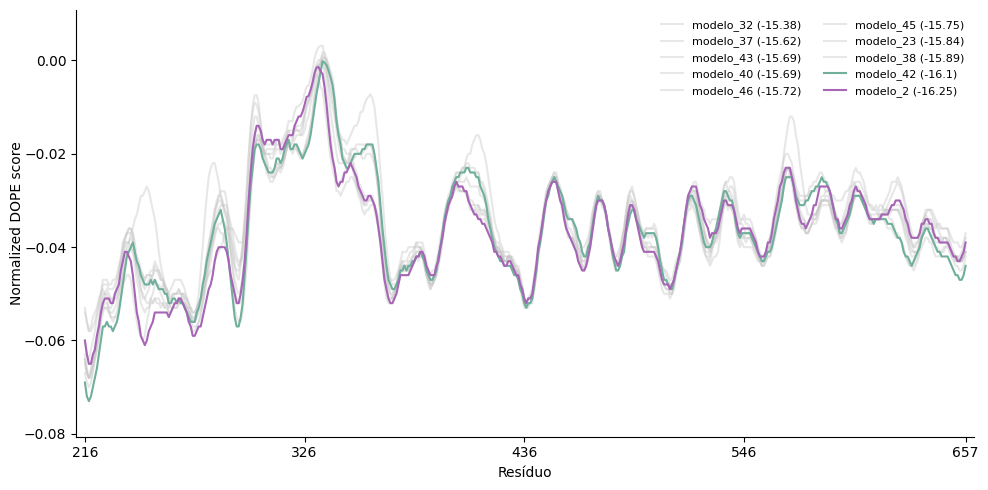

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re
import numpy as np

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, 'model*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# ordenar do menor DOPE para o maior
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 5))

cinza = "#c4c4c4"
colors = [
    cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,
    '#6FAF9C', '#A665B5'         
]
top10 = profiles_with_sum[-10:]  # pega os 10 últimos (menores DOPE)

all_dope = []
for i, (profile_path, total_sum) in enumerate(top10):
    name = os.path.basename(profile_path).replace('.profile', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 215
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 9 or i ==8 :
        alpha = 1
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha)

# Scaling
margin = (max(all_dope) - min(all_dope)) * 0.1
plt.ylim(min(all_dope) - margin, max(all_dope) + margin)

plt.xlabel('Resíduo')
plt.ylabel('Normalized DOPE score', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()
plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xlim(270, 345)
# ax.set_xticks([270, 283, 295, 310, 320, 332, 345])

first = residues.iloc[0]
last = residues.iloc[-1]
ticks = [first] + list(np.linspace(first, last, 5).astype(int)[1:-1]) + [last]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)

plt.tight_layout()
plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

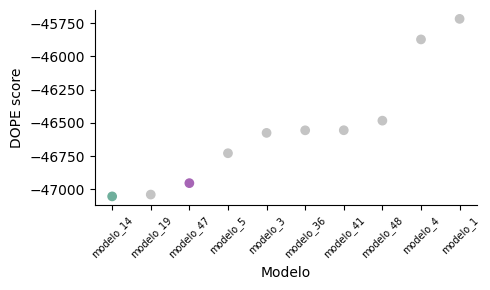

In [39]:
import matplotlib.pyplot as plt

# Ordenar do pior para o melhor (melhor fica à direita)
scores_sorted = sorted(scores, key=lambda x: x[0], reverse=False)
top10_scores = scores_sorted[-10:]

names = [s[1].replace('target.', '').replace('.pdb', '') for s in scores_sorted]
names = [re.search(r'B9999(\d+)', s[1]).group(1).lstrip('0') for s in top10_scores]
names = [f'modelo_{n}' for n in names]
dopes = [s[0] for s in top10_scores]

# Destacar o melhor (último)
colors = ['#6FAF9C'] + [cinza] + ['#A665B5'] + [cinza] * 7 

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(range(len(top10_scores)), dopes, color=colors, zorder=3)

ax.set_xlabel('Modelo')
ax.set_ylabel('DOPE score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(modelling_dir, 'dope_total.png'), dpi=150)
plt.show()